<a href="https://colab.research.google.com/github/emsofjames2003/CB2330-exercises/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Social Contacts and Mixing Patterns Relevant to the Spread of Infectious Diseases (Mossong et al., 2008) https://doi.org/10.1371/journal.pmed.0050074

**The data object**: table 1: number of participants, mean, standard deviation and relative number of reported contacts.

**The random variable chosen**: X = total number of social contacts under one day reported by an average individual

**What the paper does**: The paper presents a population-based prospective survey, where 7290 participants recorded their mixing patterns (social contacts)for one day. Different types of contacts were identified, and different parameters are associated with different average rates of contact. The categories recorded were age, day of the week, gender, country, and household size.

 The purpose of the survey is to allow modelling of transmission of infectious diseases that spread through close-contact.

**The generative model proposed**: Negative Binomail Distribution

We chose this as contacts are independent with rates of daily contacts varying from person to person.

**Parameters and assumptions**:  θ = age. We assume that age is the most important predictor of the mean daily contact rate.

**The forward simulation**:

**The parametrization/fitting**:

**What/if the model adds to the paper**:

**Model limitations/how it breaks**: The limitation of our model is that we only include age, and leave out other important factors, such as household size, day of week, gender, and country.

## The paper

Mossong et al. (2008), *Social Contacts and Mixing Patterns Relevant to the Spread of Infectious Diseases*.

https://doi.org/10.1371/journal.pmed.0050074

Our question is: How different is the number of daily contacts reported by 10–14-year-olds and people aged 70 or older?

## The data object

We use the summary results for two age groups in Table 1 of the paper:

| Age group | Participants | Mean contacts per day | Standard deviation |
|---|---:|---:|---:|
| 10–14 years | 713 | 18.22 | 12.27 |
| 70+ years | 270 | 6.89 | 5.83 |

These are published summaries. We do not have the individual contact counts from each participant.

In [17]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

Data




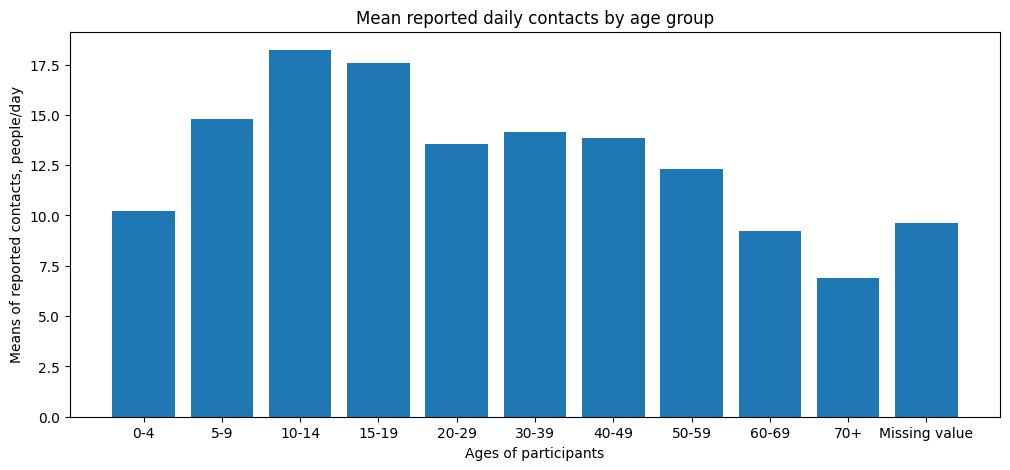

In [29]:
ages = ("0-4", "5-9", "10-14", "15-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70+", "Missing value")
number_of_participants = [660, 661, 713, 685, 879, 815, 908, 906, 728, 270, 65]
mean_reported_contacts = np.array([10.21, 14.81, 18.22, 17.58, 13.57, 14.14, 13.83, 12.30, 9.21, 6.89, 9.63])
standard_deviation_contacts = np.array([7.65, 10.09, 12.27, 12.03, 10.60, 10.15, 10.86, 10.23, 7.96, 5.83, 9.05])
variance_contacts = standard_deviation_contacts**2

plt.figure(figsize= (12, 5))
plt.bar(ages, mean_reported_contacts)
plt.xlabel("Ages of participants")
plt.ylabel("Means of reported contacts, people/day")
plt.title("Mean reported daily contacts by age group")
plt.show()

Simulating without formula

In [31]:
idx_young = 2   # 10-14
idx_old = 9     # 70+

n_young = n_part[idx_young]; mu_young = mean_contacts[idx_young]; var_y = var_contacts[idx_young]
n_old = n_part[idx_old]; mu_old = mean_contacts[idx_old]; var_y = var_contacts[idx_old]

# standard deviation
sd_y = np.sqrt(var_young / n_young)
sd_o = np.sqrt(var_old / n_old)


NameError: name 'var_young' is not defined

Proposed generative model

Likelihood & fitting

Grupp 10-14: n = 713, mean = 18.220, sd = 12.270, se = 0.4595, k = 2.509
Grupp 70+:  n = 270, mean = 6.890, sd = 5.830, se = 0.3548, k = 1.752

Skillnad i medel (10-14 minus 70+): 11.330
SE(diff) = 0.5806, z = 19.516, two-sided p-value ≈ 0.000e+00

Simulerat (N=20000):
  10-14: sim mean 18.194, sim sd 12.184, frac >20 = 0.3504
  70+:  sim mean 6.908, sim sd 5.910, frac >20 = 0.0328


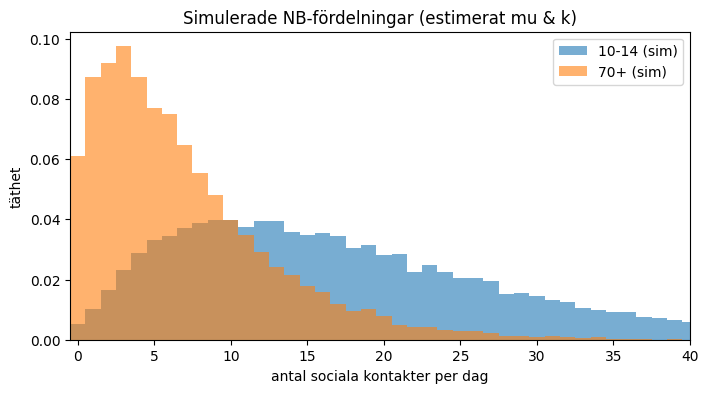

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, sqrt

# Gruppdata (bins utan "Missing value")
age_bins = ["0-4","5-9","10-14","15-19","20-29","30-39","40-49","50-59","60-69","70+"]
n_part = np.array([660, 661, 713, 685, 879, 815, 908, 906, 728, 270])
mean_contacts = np.array([10.21, 14.81, 18.22, 17.58, 13.57, 14.14, 13.83, 12.30, 9.21, 6.89])
sd_contacts = np.array([7.65, 10.09, 12.27, 12.03, 10.60, 10.15, 10.86, 10.23, 7.96, 5.83])
var_contacts = sd_contacts**2

# Index för de grupper vi vill jämföra
idx_young = 2   # 10-14
idx_old = 9     # 70+

# Extrahera per-grupp
n_y = n_part[idx_young]; mu_y = mean_contacts[idx_young]; var_y = var_contacts[idx_young]
n_o = n_part[idx_old];  mu_o = mean_contacts[idx_old];  var_o = var_contacts[idx_old]

# Standardfel för gruppmedel (eftersom vi har per-grupp var och n)
se_y = np.sqrt(var_y / n_y)
se_o = np.sqrt(var_o / n_o)

# Metod-of-moments för NB dispersion k per grupp: var = mu + mu^2/k  =>  k = mu^2 / (var - mu)
def estimate_k(mu, var):
    if var <= mu:
        return np.inf
    return mu**2 / (var - mu)

k_y = estimate_k(mu_y, var_y)
k_o = estimate_k(mu_o, var_o)

# Skillnad i medel och z-test (approximativt)
diff = mu_y - mu_o
se_diff = np.sqrt(se_y**2 + se_o**2)
z = diff / se_diff
p_two = 2 * (1 - 0.5 * (1 + erf(abs(z) / sqrt(2))))

# Skriv ut nyckeltal
print("Grupp 10-14: n = {}, mean = {:.3f}, sd = {:.3f}, se = {:.4f}, k = {:.3f}".format(
    n_y, mu_y, np.sqrt(var_y), se_y, k_y))
print("Grupp 70+:  n = {}, mean = {:.3f}, sd = {:.3f}, se = {:.4f}, k = {:.3f}".format(
    n_o, mu_o, np.sqrt(var_o), se_o, k_o))
print("\nSkillnad i medel (10-14 minus 70+): {:.3f}".format(diff))
print("SE(diff) = {:.4f}, z = {:.3f}, two-sided p-value ≈ {:.3e}".format(se_diff, z, p_two))

# Simulera individer från NB (Gamma-Poisson) för att illustrera fördelningarna
rng = np.random.default_rng(2026)
def simulate_nb(mu, k, N):
    if np.isinf(k):
        return rng.poisson(lam=mu, size=N)
    lam = rng.gamma(shape=k, scale=mu/k, size=N)
    return rng.poisson(lam)

Nsim = 20000
sim_y = simulate_nb(mu_y, k_y, Nsim)
sim_o = simulate_nb(mu_o, k_o, Nsim)

print("\nSimulerat (N={}):".format(Nsim))
print("  10-14: sim mean {:.3f}, sim sd {:.3f}, frac >20 = {:.4f}".format(sim_y.mean(), sim_y.std(ddof=1), (sim_y>20).mean()))
print("  70+:  sim mean {:.3f}, sim sd {:.3f}, frac >20 = {:.4f}".format(sim_o.mean(), sim_o.std(ddof=1), (sim_o>20).mean()))

# Plotta simulerade fördelningar
plt.figure(figsize=(8,4))
maxx = max(sim_y.max(), sim_o.max(), 40)
bins = np.arange(0, min(maxx,60)+1) - 0.5
plt.hist(sim_y, bins=bins, density=True, alpha=0.6, label='10-14 (sim)')
plt.hist(sim_o, bins=bins, density=True, alpha=0.6, label='70+ (sim)')
plt.xlim(-0.5, 40)
plt.xlabel("antal sociala kontakter per dag")
plt.ylabel("täthet")
plt.legend()
plt.title("Simulerade NB-fördelningar (estimerat mu & k)")
plt.show()
